
# DeepLense Specific Test VII — Tier 2: Eqv-AC-PT-PINN

This notebook builds **Tier 2** on top of the earlier Eqv-LensPINN baseline.

## What changed from Tier 1

**Tier 1 (Eqv-LensPINN)**
- C8-equivariant visual trunk
- explicit lens-physics branch with `psi`, `alpha`, `kappa`, `gamma`
- source / relensed auxiliary path
- pooled physics features concatenated with visual features

**Tier 2 (Eqv-AC-PT-PINN)**
- keeps the **C8-equivariant trunk**
- **removes heavy source reconstruction as the main information bottleneck**
- adds a **multi-scale physics decoder** on top of equivariant feature maps
- predicts **both** `psi` and `alpha_pred`
- enforces **alpha-consistency PINN constraints**:
  - `alpha_pred ≈ grad(psi)`
  - `div(alpha_pred) ≈ laplacian(psi)`
  - `curl(alpha_pred) ≈ 0`
- builds a structured **physics tensor** from
  - `alpha_pred`
  - `alpha_grad`
  - `alpha_resid`
  - `kappa`
  - `gamma_mag`
  - `criticality`
  - a **light source-plane proxy** obtained via `beta = theta - alpha`
- turns those maps into **physics tokens**
- uses **cross-attention from visual tokens to physics tokens** instead of only late pooled fusion
- keeps a **curriculum / gate** so physics helps only after the visual trunk has started learning

## Why this is a real Tier 2 step

Tier 1 proved that equivariant PINN training is stable. Tier 2 tries to improve on it by:
1. preserving the strong symmetry prior,
2. making the physics branch more explicit and more structured,
3. replacing fragile source-reconstruction-heavy fusion with token-level interaction,
4. keeping the lens equation inside the architecture without making optimization depend entirely on reconstruction.

This notebook is designed for **Kaggle P100 16 GB**, uses the provided `train/` and `val/` split directly, and supports `.npy` lens images.


In [15]:

# # ============================================================
# # 0) Bootstrap for Kaggle P100 (Pascal sm_60) + escnn install
# # Run this cell FIRST. If it exits, restart the kernel and rerun.
# # ============================================================
# import sys
# import subprocess
# import importlib.util

# NEED_RESTART = False

# def _run(cmd):
#     print(" ".join(cmd))
#     subprocess.check_call(cmd)

# import torch

# print("Preinstalled torch:", torch.__version__)
# print("Preinstalled torch CUDA:", torch.version.cuda)
# print("CUDA available:", torch.cuda.is_available())
# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))
#     print("Compute capability:", torch.cuda.get_device_capability(0))

# # P100 / Pascal fix: keep cu126 if Kaggle upgrades to a CUDA >= 12.8 wheel
# if torch.cuda.is_available():
#     cc_major, cc_minor = torch.cuda.get_device_capability(0)
#     cuda_ver = tuple(int(x) for x in str(torch.version.cuda).split(".")[:2]) if torch.version.cuda else (0, 0)
#     if cc_major == 6 and cuda_ver >= (12, 8):
#         _run([
#             sys.executable, "-m", "pip", "install", "-q", "--upgrade",
#             "torch==2.9.1", "torchvision==0.24.1", "torchaudio==2.9.1",
#             "--index-url", "https://download.pytorch.org/whl/cu126",
#         ])
#         NEED_RESTART = True

# if importlib.util.find_spec("escnn") is None:
#     installed = False
#     candidates = [
#         [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "escnn==1.0.11"],
#         [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "escnn"],
#         [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "git+https://github.com/QUVA-Lab/escnn"],
#     ]
#     for cmd in candidates:
#         try:
#             _run(cmd)
#             installed = True
#             NEED_RESTART = True
#             break
#         except subprocess.CalledProcessError as e:
#             print("Install attempt failed:", e)
#     if not installed:
#         raise RuntimeError("Could not install escnn from PyPI or GitHub.")

# if NEED_RESTART:
#     raise SystemExit("Installed/updated packages. Restart the Kaggle kernel, then rerun from the top.")
# else:
#     print("Environment looks ready.")


In [16]:

# =========================
# 1) Imports
# =========================
import os
import gc
import math
import time
import json
import copy
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from escnn import gspaces, nn as enn

warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("torch CUDA runtime:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    print("compute capability:", torch.cuda.get_device_capability(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


torch: 2.9.1+cu126
torch CUDA runtime: 12.6
cuda available: True
device: Tesla P100-PCIE-16GB
compute capability: (6, 0)


In [17]:

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    # paths
    dataset_root: str = "/kaggle/input/datasets/hansika972/dataset-task-vii/dataset"
    work_dir: str = "/kaggle/working/eqv_acpt_pinn_tier2"

    # split handling
    merge_train_val: bool = False
    val_size: float = 0.10
    seed: int = 42

    # data
    img_size: int = 160
    physics_size: int = 96
    class_names: Tuple[str, ...] = ("no", "sphere", "vort")
    batch_size: int = 12
    num_workers: int = 2
    pin_memory: bool = True

    # optimization
    epochs: int = 48
    warmup_epochs: int = 5
    ramp_epochs: int = 15
    physics_gate_max: float = 0.80
    lr: float = 2e-4
    min_lr: float = 5e-6
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    use_amp: bool = True
    label_smoothing: float = 0.03
    early_stopping_patience: int = 12

    # model
    group_order: int = 8
    base_reps: int = 12
    drop_rate: float = 0.15
    token_dim: int = 192
    token_grid: int = 4
    attn_heads: int = 6
    attn_depth: int = 2
    mlp_ratio: float = 3.0
    physics_hidden: int = 64
    scalar_hidden: int = 64

    # losses
    w_cls: float = 1.0
    w_aux_cls: float = 0.20
    w_alpha_cons: float = 0.03
    w_div: float = 0.015
    w_curl: float = 0.005
    w_tv: float = 1e-4
    w_token_cons: float = 0.0   # reserved; kept 0 by default

    # evaluation / saving
    top_k: int = 3
    use_d4_tta: bool = True

CFG = CFG()
os.makedirs(CFG.work_dir, exist_ok=True)

CLASS_TO_IDX = {c: i for i, c in enumerate(CFG.class_names)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

# robust dataset root resolution
DATASET_CANDIDATES = [
    CFG.dataset_root,
    "/kaggle/input/datasets/ashaeyx/dataset-task-vii/dataset",
    "/kaggle/input/dataset-task-vii/dataset",
    "/kaggle/input/datasets/akhilesharu/dataset-task-vii/dataset",
]

def resolve_dataset_root(candidates: List[str]) -> str:
    for p in candidates:
        root = Path(p)
        if (root / "train").exists() and (root / "val").exists():
            return str(root)
    raise FileNotFoundError(
        "Could not find dataset root with train/ and val/. Checked: " + json.dumps(candidates)
    )

CFG.dataset_root = resolve_dataset_root(DATASET_CANDIDATES)
print("Using dataset root:", CFG.dataset_root)
print("Using work dir:", CFG.work_dir)


Using dataset root: /kaggle/input/datasets/akhilesharu/dataset-task-vii/dataset
Using work dir: /kaggle/working/eqv_acpt_pinn_tier2


In [18]:

# =========================
# 3) Reproducibility
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(CFG.seed)


In [19]:

# =========================
# 4) Dataset indexing
# =========================
def index_split(root: Path, split_name: str, class_names: Tuple[str, ...]):
    rows = []
    split_root = root / split_name
    if not split_root.exists():
        raise FileNotFoundError(f"Missing split directory: {split_root}")

    for cname in class_names:
        class_dir = split_root / cname
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class directory: {class_dir}")

        files = sorted(class_dir.glob("*.npy"))
        if len(files) == 0:
            raise RuntimeError(f"No .npy files found under {class_dir}")

        for p in files:
            rows.append({
                "path": str(p),
                "label_name": cname,
                "label": CLASS_TO_IDX[cname],
                "split": split_name,
            })

    return pd.DataFrame(rows)


def make_splits(cfg: CFG):
    root = Path(cfg.dataset_root)
    train_df = index_split(root, "train", cfg.class_names)
    val_df = index_split(root, "val", cfg.class_names)

    if cfg.merge_train_val:
        full_df = pd.concat([train_df, val_df], ignore_index=True)
        train_parts, val_parts = [], []
        rng = np.random.default_rng(cfg.seed)
        for c in cfg.class_names:
            cdf = full_df[full_df.label_name == c].sample(frac=1.0, random_state=cfg.seed).reset_index(drop=True)
            n_val = max(1, int(round(len(cdf) * cfg.val_size)))
            idx = np.arange(len(cdf))
            rng.shuffle(idx)
            val_idx = set(idx[:n_val].tolist())
            train_parts.append(cdf[~cdf.index.isin(val_idx)].copy())
            val_parts.append(cdf[cdf.index.isin(val_idx)].copy())
        train_df = pd.concat(train_parts, ignore_index=True)
        val_df = pd.concat(val_parts, ignore_index=True)

    print("train size:", len(train_df), "| val size:", len(val_df))
    print("train class counts:\n", train_df.label_name.value_counts().sort_index())
    print("val class counts:\n", val_df.label_name.value_counts().sort_index())
    return train_df, val_df

train_df, val_df = make_splits(CFG)
train_df.head()


train size: 30000 | val size: 7500
train class counts:
 label_name
no        10000
sphere    10000
vort      10000
Name: count, dtype: int64
val class counts:
 label_name
no        2500
sphere    2500
vort      2500
Name: count, dtype: int64


,path,label_name,label,split
0,/kaggle/input/datasets/akhilesharu/dataset-tas...,no,0,train
1,/kaggle/input/datasets/akhilesharu/dataset-tas...,no,0,train
2,/kaggle/input/datasets/akhilesharu/dataset-tas...,no,0,train
3,/kaggle/input/datasets/akhilesharu/dataset-tas...,no,0,train
4,/kaggle/input/datasets/akhilesharu/dataset-tas...,no,0,train


In [20]:

# =========================
# 5) Augmentations / dataset / loaders
# =========================
class LensDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_size: int, train: bool):
        self.df = df.reset_index(drop=True)
        self.img_size = int(img_size)
        self.train = bool(train)

    def __len__(self):
        return len(self.df)

    def _load_npy(self, path: str):
        arr = np.load(path)
        arr = np.asarray(arr, dtype=np.float32)

        if arr.ndim == 3:
            if arr.shape[0] == 1:
                arr = arr[0]
            elif arr.shape[-1] == 1:
                arr = arr[..., 0]
            else:
                arr = arr[..., 0]

        if arr.ndim != 2:
            raise ValueError(f"Expected 2D lens image, got shape {arr.shape} for {path}")

        amin, amax = float(arr.min()), float(arr.max())
        if amin < -1e-6 or amax > 1.0 + 1e-6:
            arr = (arr - amin) / (amax - amin + 1e-8)

        arr = np.clip(arr, 0.0, 1.0)
        return arr

    def _resize(self, x: np.ndarray):
        t = torch.from_numpy(x).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(t, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
        return t[0, 0].numpy()

    def _d4_aug(self, x: np.ndarray):
        k = np.random.randint(0, 4)
        x = np.rot90(x, k).copy()
        if np.random.rand() < 0.5:
            x = np.fliplr(x).copy()
        if np.random.rand() < 0.5:
            x = np.flipud(x).copy()
        return x

    def _photometric_aug(self, x: np.ndarray):
        if np.random.rand() < 0.35:
            gain = np.random.uniform(0.9, 1.1)
            bias = np.random.uniform(-0.03, 0.03)
            x = x * gain + bias
        if np.random.rand() < 0.25:
            gamma = np.random.uniform(0.9, 1.1)
            x = np.power(np.clip(x, 0, 1), gamma)
        return np.clip(x, 0.0, 1.0)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        x = self._load_npy(row.path)
        x = self._resize(x)
        if self.train:
            x = self._d4_aug(x)
            x = self._photometric_aug(x)

        x = torch.from_numpy(x).unsqueeze(0).float()
        y = torch.tensor(int(row.label), dtype=torch.long)
        return {"image": x, "label": y, "path": row.path}


def build_loaders(cfg: CFG, train_df: pd.DataFrame, val_df: pd.DataFrame):
    train_ds = LensDataset(train_df, cfg.img_size, train=True)
    val_ds = LensDataset(val_df, cfg.img_size, train=False)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
        drop_last=False,
    )
    return train_loader, val_loader

train_loader, val_loader = build_loaders(CFG, train_df, val_df)
batch = next(iter(train_loader))
print(batch["image"].shape, batch["label"].shape)


torch.Size([12, 1, 160, 160]) torch.Size([12])


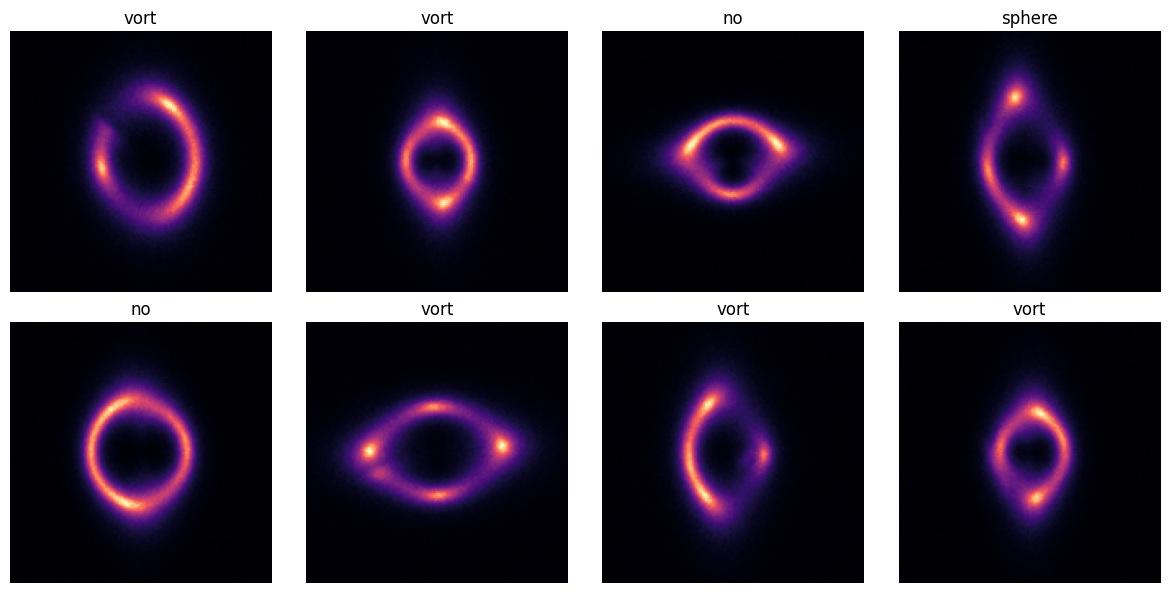

In [21]:

# =========================
# 6) Visual sanity check
# =========================
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i in range(8):
    img = batch["image"][i, 0].numpy()
    lbl = batch["label"][i].item()
    axes[i].imshow(img, cmap="magma")
    axes[i].set_title(IDX_TO_CLASS[lbl])
    axes[i].axis("off")
plt.tight_layout()
plt.show()


In [22]:

# =========================
# 7) Math helpers
# =========================
def make_coord_grid(batch_size: int, h: int, w: int, device, dtype):
    ys = torch.linspace(-1.0, 1.0, h, device=device, dtype=dtype)
    xs = torch.linspace(-1.0, 1.0, w, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    grid = torch.stack([xx, yy], dim=-1)
    return grid.unsqueeze(0).repeat(batch_size, 1, 1, 1)


def _fixed_kernel(weight, channels, device, dtype):
    k = torch.tensor(weight, device=device, dtype=dtype).view(1, 1, 3, 3)
    return k.repeat(channels, 1, 1, 1)


def gradients_xy(x: torch.Tensor):
    c = x.shape[1]
    kx = _fixed_kernel([[0, 0, 0], [-0.5, 0.0, 0.5], [0, 0, 0]], c, x.device, x.dtype)
    ky = _fixed_kernel([[0, -0.5, 0], [0, 0.0, 0], [0, 0.5, 0]], c, x.device, x.dtype)
    xpad = F.pad(x, (1, 1, 1, 1), mode="replicate")
    gx = F.conv2d(xpad, kx, groups=c)
    gy = F.conv2d(xpad, ky, groups=c)
    return gx, gy


def divergence(v: torch.Tensor):
    vx, vy = v[:, 0:1], v[:, 1:2]
    dvx_dx, _ = gradients_xy(vx)
    _, dvy_dy = gradients_xy(vy)
    return dvx_dx + dvy_dy


def curl2d(v: torch.Tensor):
    vx, vy = v[:, 0:1], v[:, 1:2]
    _, dvx_dy = gradients_xy(vx)
    dvy_dx, _ = gradients_xy(vy)
    return dvy_dx - dvx_dy


def laplacian(x: torch.Tensor):
    c = x.shape[1]
    kl = _fixed_kernel([[0, 1, 0], [1, -4, 1], [0, 1, 0]], c, x.device, x.dtype)
    xpad = F.pad(x, (1, 1, 1, 1), mode="replicate")
    return F.conv2d(xpad, kl, groups=c)


def total_variation(x: torch.Tensor):
    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    return dx.abs().mean() + dy.abs().mean()


def safe_std(x: torch.Tensor, dims=None, keepdim=False, eps=1e-6):
    if dims is None:
        dims = tuple(range(x.ndim))
    mean = x.mean(dim=dims, keepdim=True)
    var = ((x - mean) ** 2).mean(dim=dims, keepdim=True)
    std = torch.sqrt(var + eps)
    if not keepdim:
        for d in sorted(dims, reverse=True):
            std = std.squeeze(d)
    return std


In [23]:

# =========================
# 8) Model blocks
# =========================
def pick_gn_groups(channels: int, max_groups: int = 8) -> int:
    for g in range(min(max_groups, channels), 0, -1):
        if channels % g == 0:
            return g
    return 1


class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, drop=0.0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)
        self.norm = nn.GroupNorm(pick_gn_groups(out_ch), out_ch)
        self.act = nn.SiLU(inplace=True)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.act(self.norm(self.conv(x))))


class PhysicsFPN(nn.Module):
    def __init__(self, c2_ch: int, c3_ch: int, c4_ch: int, out_ch: int = 64, drop: float = 0.1):
        super().__init__()
        self.img_stem = nn.Sequential(
            ConvGNAct(1, 16, 3, 1, 1, drop=0.0),
            ConvGNAct(16, out_ch, 3, 1, 1, drop=drop),
        )
        self.lat2 = nn.Sequential(nn.Conv2d(c2_ch, out_ch, 1, bias=False), nn.GroupNorm(pick_gn_groups(out_ch), out_ch), nn.SiLU(inplace=True))
        self.lat3 = nn.Sequential(nn.Conv2d(c3_ch, out_ch, 1, bias=False), nn.GroupNorm(pick_gn_groups(out_ch), out_ch), nn.SiLU(inplace=True))
        self.lat4 = nn.Sequential(nn.Conv2d(c4_ch, out_ch, 1, bias=False), nn.GroupNorm(pick_gn_groups(out_ch), out_ch), nn.SiLU(inplace=True))

        self.fuse = nn.Sequential(
            ConvGNAct(out_ch * 4, out_ch * 2, 3, 1, 1, drop=drop),
            ConvGNAct(out_ch * 2, out_ch, 3, 1, 1, drop=drop),
        )

        self.psi_head = nn.Sequential(
            ConvGNAct(out_ch, out_ch, 3, 1, 1, drop=drop),
            nn.Conv2d(out_ch, 1, 1),
        )
        self.alpha_head = nn.Sequential(
            ConvGNAct(out_ch, out_ch, 3, 1, 1, drop=drop),
            nn.Conv2d(out_ch, 2, 1),
        )

    def forward(self, x_phy: torch.Tensor, feats: Dict[str, torch.Tensor]):
        h, w = x_phy.shape[-2:]
        i = self.img_stem(x_phy)
        f2 = F.interpolate(self.lat2(feats["c2"]), size=(h, w), mode="bilinear", align_corners=False)
        f3 = F.interpolate(self.lat3(feats["c3"]), size=(h, w), mode="bilinear", align_corners=False)
        f4 = F.interpolate(self.lat4(feats["c4"]), size=(h, w), mode="bilinear", align_corners=False)
        fused = self.fuse(torch.cat([i, f2, f3, f4], dim=1))
        psi = 0.25 * torch.tanh(self.psi_head(fused))
        alpha_pred = 0.50 * torch.tanh(self.alpha_head(fused))
        return fused, psi, alpha_pred


class PhysicsTokenizer(nn.Module):
    def __init__(self, in_ch: int, token_dim: int, token_grid: int = 4, drop: float = 0.1):
        super().__init__()
        self.token_grid = int(token_grid)
        self.embed = nn.Sequential(
            ConvGNAct(in_ch, token_dim // 2, 3, 1, 1, drop=drop),
            ConvGNAct(token_dim // 2, token_dim, 3, 1, 1, drop=drop),
        )
        self.pos = nn.Parameter(torch.zeros(1, token_grid * token_grid, token_dim))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x: torch.Tensor):
        x = self.embed(x)
        x = F.adaptive_avg_pool2d(x, (self.token_grid, self.token_grid))
        x = x.flatten(2).transpose(1, 2)
        return x + self.pos


class VisualTokenizer(nn.Module):
    def __init__(self, in_ch: int, token_dim: int, token_grid: int = 4, drop: float = 0.1):
        super().__init__()
        self.token_grid = int(token_grid)
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch, token_dim, 1, bias=False),
            nn.BatchNorm2d(token_dim),
            nn.SiLU(inplace=True),
            nn.Dropout2d(drop),
        )
        self.pos = nn.Parameter(torch.zeros(1, token_grid * token_grid, token_dim))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x: torch.Tensor):
        x = self.proj(x)
        x = F.adaptive_avg_pool2d(x, (self.token_grid, self.token_grid))
        x = x.flatten(2).transpose(1, 2)
        return x + self.pos


class CrossAttentionBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 3.0, drop: float = 0.1):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads=num_heads, dropout=drop, batch_first=True)
        self.drop_path = nn.Dropout(drop)
        self.norm_ff = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden, dim),
            nn.Dropout(drop),
        )

    def forward(self, q: torch.Tensor, kv: torch.Tensor):
        qn = self.norm_q(q)
        kvn = self.norm_kv(kv)
        attn_out, _ = self.attn(qn, kvn, kvn, need_weights=False)
        q = q + self.drop_path(attn_out)
        q = q + self.ff(self.norm_ff(q))
        return q


In [24]:

# =========================
# 9) Tier 2 model: Eqv-AC-PT-PINN
# =========================
class C8SteerableFPNBackbone(nn.Module):
    def __init__(self, group_order=8, base_reps=12, drop_rate=0.15):
        super().__init__()
        self.r2 = gspaces.rot2dOnR2(N=group_order)

        in_type = enn.FieldType(self.r2, [self.r2.trivial_repr])
        t1 = enn.FieldType(self.r2, base_reps * [self.r2.regular_repr])
        t2 = enn.FieldType(self.r2, (base_reps + 6) * [self.r2.regular_repr])
        t3 = enn.FieldType(self.r2, (base_reps + 12) * [self.r2.regular_repr])
        t4 = enn.FieldType(self.r2, (base_reps + 20) * [self.r2.regular_repr])

        self.block1 = enn.SequentialModule(
            enn.R2Conv(in_type, t1, kernel_size=7, padding=3, bias=False),
            enn.InnerBatchNorm(t1),
            enn.ReLU(t1, inplace=True),
        )
        self.pool1 = enn.PointwiseAvgPoolAntialiased(t1, sigma=0.66, stride=2)

        self.block2 = enn.SequentialModule(
            enn.R2Conv(t1, t2, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(t2),
            enn.ReLU(t2, inplace=True),
        )
        self.pool2 = enn.PointwiseAvgPoolAntialiased(t2, sigma=0.66, stride=2)

        self.block3 = enn.SequentialModule(
            enn.R2Conv(t2, t3, kernel_size=5, padding=2, bias=False),
            enn.InnerBatchNorm(t3),
            enn.ReLU(t3, inplace=True),
        )
        self.pool3 = enn.PointwiseAvgPoolAntialiased(t3, sigma=0.66, stride=2)

        self.block4 = enn.SequentialModule(
            enn.R2Conv(t3, t4, kernel_size=3, padding=1, bias=False),
            enn.InnerBatchNorm(t4),
            enn.ReLU(t4, inplace=True),
        )

        self.gpool2 = enn.GroupPooling(t2)
        self.gpool3 = enn.GroupPooling(t3)
        self.gpool4 = enn.GroupPooling(t4)
        self.drop = nn.Dropout(drop_rate)

        self.c2_ch = len(self.gpool2.out_type.representations)
        self.c3_ch = len(self.gpool3.out_type.representations)
        self.c4_ch = len(self.gpool4.out_type.representations)
        self.out_dim = self.c4_ch

    def forward(self, x: torch.Tensor):
        gx = enn.GeometricTensor(x, enn.FieldType(self.r2, [self.r2.trivial_repr]))

        x1 = self.block1(gx)
        x1p = self.pool1(x1)

        x2 = self.block2(x1p)
        c2 = self.gpool2(x2).tensor
        x2p = self.pool2(x2)

        x3 = self.block3(x2p)
        c3 = self.gpool3(x3).tensor
        x3p = self.pool3(x3)

        x4 = self.block4(x3p)
        c4 = self.gpool4(x4).tensor

        pooled = self.drop(c4.mean(dim=(-1, -2)))
        feats = {"c2": c2, "c3": c3, "c4": c4}
        return pooled, feats


class EqvACPTPINN(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.visual = C8SteerableFPNBackbone(cfg.group_order, cfg.base_reps, cfg.drop_rate)

        self.physics_decoder = PhysicsFPN(
            c2_ch=self.visual.c2_ch,
            c3_ch=self.visual.c3_ch,
            c4_ch=self.visual.c4_ch,
            out_ch=cfg.physics_hidden,
            drop=cfg.drop_rate,
        )

        # 10-channel physics tensor: alpha_pred(2), alpha_grad(2), alpha_resid(2),
        # kappa(1), gamma_mag(1), criticality(1), source_proxy(1)
        self.physics_tokenizer = PhysicsTokenizer(
            in_ch=10,
            token_dim=cfg.token_dim,
            token_grid=cfg.token_grid,
            drop=cfg.drop_rate,
        )
        self.visual_tokenizer = VisualTokenizer(
            in_ch=self.visual.c4_ch,
            token_dim=cfg.token_dim,
            token_grid=cfg.token_grid,
            drop=cfg.drop_rate,
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.token_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.cross_blocks = nn.ModuleList([
            CrossAttentionBlock(cfg.token_dim, cfg.attn_heads, cfg.mlp_ratio, cfg.drop_rate)
            for _ in range(cfg.attn_depth)
        ])

        self.scalar_mlp = nn.Sequential(
            nn.Linear(8, cfg.scalar_hidden),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(cfg.scalar_hidden, cfg.scalar_hidden),
            nn.SiLU(inplace=True),
        )

        self.aux_classifier = nn.Sequential(
            nn.Linear(self.visual.out_dim, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(64, len(cfg.class_names)),
        )

        fusion_dim = self.visual.out_dim + cfg.token_dim + cfg.token_dim + cfg.scalar_hidden
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(256, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(128, len(cfg.class_names)),
        )

        self.physics_gate = 0.0

    def set_physics_gate(self, gate: float):
        self.physics_gate = float(gate)

    def forward(self, x: torch.Tensor):
        b = x.shape[0]
        x = x.float()
        x_std = (x - x.mean(dim=(-1, -2), keepdim=True)) / (x.std(dim=(-1, -2), keepdim=True) + 1e-6)

        visual_vec, feats = self.visual(x_std)
        aux_logits = self.aux_classifier(visual_vec)

        x_phy = F.interpolate(x, size=(self.cfg.physics_size, self.cfg.physics_size), mode="bilinear", align_corners=False)
        fused_phy, psi, alpha_pred = self.physics_decoder(x_phy, feats)

        alpha_grad = torch.cat(gradients_xy(psi), dim=1)
        psi_x, psi_y = gradients_xy(psi)
        psi_xx, psi_xy = gradients_xy(psi_x)
        psi_yx, psi_yy = gradients_xy(psi_y)

        kappa = 0.5 * (psi_xx + psi_yy)
        gamma1_map = 0.5 * (psi_xx - psi_yy)
        gamma2_map = 0.5 * (psi_xy + psi_yx)
        gamma_mag = torch.sqrt(gamma1_map ** 2 + gamma2_map ** 2 + 1e-8)

        div_alpha = divergence(alpha_pred)
        curl_alpha = curl2d(alpha_pred)
        alpha_resid = alpha_pred - alpha_grad

        # lens-equation-conditioned source proxy (lightweight; no full reconstruction bottleneck)
        xx_yy = make_coord_grid(b, self.cfg.physics_size, self.cfg.physics_size, x.device, x.dtype)
        xx = xx_yy[..., 0].unsqueeze(1)
        yy = xx_yy[..., 1].unsqueeze(1)
        alpha_blend = 0.5 * (alpha_pred + alpha_grad)
        beta_x = (xx - alpha_blend[:, 0:1]).clamp(-1.0, 1.0)
        beta_y = (yy - alpha_blend[:, 1:2]).clamp(-1.0, 1.0)
        beta_grid = torch.stack([beta_x[:, 0], beta_y[:, 0]], dim=-1)
        source_proxy = F.grid_sample(x_phy, beta_grid, mode="bilinear", padding_mode="zeros", align_corners=True)

        detA = (1.0 - (kappa + gamma1_map)) * (1.0 - (kappa - gamma1_map)) - gamma2_map ** 2
        criticality = torch.sigmoid(8.0 * (0.15 - detA.abs()))

        physics_tensor = torch.cat([
            alpha_pred,
            alpha_grad,
            alpha_resid,
            kappa,
            gamma_mag,
            criticality,
            source_proxy,
        ], dim=1)
        if physics_tensor.shape[1] != 10:
            raise RuntimeError(f"physics_tensor expected 10 channels, got {physics_tensor.shape[1]}")

        physics_tokens = self.physics_tokenizer(physics_tensor)
        visual_tokens = self.visual_tokenizer(feats["c4"])

        gate = self.physics_gate
        physics_tokens = physics_tokens * gate
        cls = self.cls_token.expand(b, -1, -1)
        vis_seq = torch.cat([cls, visual_tokens], dim=1)
        for blk in self.cross_blocks:
            vis_seq = blk(vis_seq, physics_tokens)
        cls_out = vis_seq[:, 0]

        physics_global = physics_tokens.mean(dim=1)
        scalar_stats = torch.cat([
            kappa.mean(dim=(1, 2, 3)).unsqueeze(1),
            safe_std(kappa, dims=(1, 2, 3)).unsqueeze(1),
            gamma_mag.mean(dim=(1, 2, 3)).unsqueeze(1),
            safe_std(gamma_mag, dims=(1, 2, 3)).unsqueeze(1),
            criticality.mean(dim=(1, 2, 3)).unsqueeze(1),
            safe_std(criticality, dims=(1, 2, 3)).unsqueeze(1),
            alpha_resid.abs().mean(dim=(1, 2, 3)).unsqueeze(1),
            source_proxy.mean(dim=(1, 2, 3)).unsqueeze(1),
        ], dim=1)
        scalar_feat = self.scalar_mlp(scalar_stats) * gate

        fused = torch.cat([visual_vec, cls_out, physics_global, scalar_feat], dim=1)
        logits = self.classifier(fused)

        aux = {
            "x_phy": x_phy,
            "fused_phy": fused_phy,
            "psi": psi,
            "alpha_pred": alpha_pred,
            "alpha_grad": alpha_grad,
            "alpha_resid": alpha_resid,
            "div_alpha": div_alpha,
            "curl_alpha": curl_alpha,
            "kappa": kappa,
            "gamma_mag": gamma_mag,
            "criticality": criticality,
            "source_proxy": source_proxy,
            "physics_tensor": physics_tensor,
            "physics_gate": gate,
            "aux_logits": aux_logits,
        }
        return logits, aux


In [25]:

# =========================
# 10) Loss / schedules / metrics / checkpoints
# =========================
class HybridTier2Loss(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
        self.gate = 0.0
        self.w_cls = cfg.w_cls
        self.w_aux_cls = cfg.w_aux_cls
        self.w_alpha_cons = cfg.w_alpha_cons
        self.w_div = cfg.w_div
        self.w_curl = cfg.w_curl
        self.w_tv = cfg.w_tv
        self.w_token_cons = cfg.w_token_cons

    def set_gate(self, gate: float):
        self.gate = float(gate)

    def forward(self, logits, targets, aux):
        loss_cls = self.ce(logits, targets)
        loss_aux_cls = self.ce(aux["aux_logits"], targets)
        loss_alpha_cons = F.smooth_l1_loss(aux["alpha_pred"], aux["alpha_grad"].detach())
        loss_div = F.smooth_l1_loss(aux["div_alpha"], laplacian(aux["psi"]).detach())
        loss_curl = F.smooth_l1_loss(aux["curl_alpha"], torch.zeros_like(aux["curl_alpha"]))
        loss_tv = total_variation(aux["psi"])
        loss_token_cons = aux["alpha_resid"].abs().mean()

        gate = self.gate
        total = (
            self.w_cls * loss_cls
            + self.w_aux_cls * loss_aux_cls
            + gate * self.w_alpha_cons * loss_alpha_cons
            + gate * self.w_div * loss_div
            + gate * self.w_curl * loss_curl
            + gate * self.w_tv * loss_tv
            + gate * self.w_token_cons * loss_token_cons
        )

        logs = {
            "loss_cls": float(loss_cls.detach().cpu()),
            "loss_aux_cls": float(loss_aux_cls.detach().cpu()),
            "loss_alpha_cons": float(loss_alpha_cons.detach().cpu()),
            "loss_div": float(loss_div.detach().cpu()),
            "loss_curl": float(loss_curl.detach().cpu()),
            "loss_tv": float(loss_tv.detach().cpu()),
            "loss_token_cons": float(loss_token_cons.detach().cpu()),
            "physics_gate": float(gate),
        }
        return total, logs


def physics_gate_for_epoch(epoch: int, cfg: CFG):
    if epoch <= cfg.warmup_epochs:
        return 0.0
    progress = (epoch - cfg.warmup_epochs) / max(1, cfg.ramp_epochs)
    progress = min(max(progress, 0.0), 1.0)
    # smoother-than-linear ramp
    return float(cfg.physics_gate_max * (0.5 - 0.5 * math.cos(math.pi * progress)))


def multiclass_metrics(y_true, probs):
    y_true = np.asarray(y_true, dtype=np.int64)
    probs = np.asarray(probs, dtype=np.float64)

    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, 1e-12, 1.0)
    probs = probs / probs.sum(axis=1, keepdims=True).clip(min=1e-12)

    y_pred = probs.argmax(axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    present_classes = np.unique(y_true)
    num_classes = probs.shape[1]

    per_class_auc = {}
    for c in range(num_classes):
        y_bin = (y_true == c).astype(np.int32)
        if y_bin.min() == y_bin.max():
            per_class_auc[IDX_TO_CLASS[c]] = np.nan
        else:
            per_class_auc[IDX_TO_CLASS[c]] = roc_auc_score(y_bin, probs[:, c])

    if len(present_classes) == num_classes:
        macro_auc_ovr = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
        weighted_auc_ovr = roc_auc_score(y_true, probs, multi_class="ovr", average="weighted")
    else:
        valid_aucs = [v for v in per_class_auc.values() if not np.isnan(v)]
        macro_auc_ovr = float(np.mean(valid_aucs)) if len(valid_aucs) > 0 else np.nan
        weighted_auc_ovr = macro_auc_ovr

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_auc_ovr": macro_auc_ovr,
        "weighted_auc_ovr": weighted_auc_ovr,
        "per_class_auc": per_class_auc,
        "y_pred": y_pred,
    }


def _sanitize_for_save(obj):
    if isinstance(obj, dict):
        return {str(k): _sanitize_for_save(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_sanitize_for_save(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


class TopKCheckpointManager:
    def __init__(self, work_dir: str, top_k: int = 3):
        self.work_dir = work_dir
        self.top_k = int(top_k)
        self.records = []

    def maybe_save(self, model: nn.Module, epoch: int, metrics: Dict, cfg: CFG):
        score = float(metrics["macro_auc_ovr"])
        fname = f"epoch{epoch:03d}_auc{score:.6f}.pth"
        path = os.path.join(self.work_dir, fname)

        torch.save(
            {
                "epoch": int(epoch),
                "model_state": model.state_dict(),
                "metrics": _sanitize_for_save({k: v for k, v in metrics.items() if k != "y_pred"}),
                "config": _sanitize_for_save(asdict(cfg)),
            },
            path,
        )
        self.records.append({"score": score, "path": path})
        self.records = sorted(self.records, key=lambda x: x["score"], reverse=True)

        while len(self.records) > self.top_k:
            trash = self.records.pop(-1)
            if os.path.exists(trash["path"]):
                os.remove(trash["path"])
        return copy.deepcopy(self.records)


def load_checkpoint_state(path: str, device):
    obj = torch.load(path, map_location=device, weights_only=False)
    if isinstance(obj, dict) and "model_state" in obj:
        return obj["model_state"], obj
    if isinstance(obj, dict):
        return obj, {"model_state": obj}
    raise ValueError(f"Unsupported checkpoint format: {path}")


In [26]:

# =========================
# 11) Build model
# =========================
model = EqvACPTPINN(CFG).to(DEVICE)
criterion = HybridTier2Loss(CFG)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs, eta_min=CFG.min_lr)
scaler = torch.amp.GradScaler("cuda", enabled=(CFG.use_amp and torch.cuda.is_available()))
ckpt_mgr = TopKCheckpointManager(CFG.work_dir, CFG.top_k)

# quick initialization forward so all parameters are materialized before counting
with torch.no_grad():
    _ = model(batch["image"][:2].to(DEVICE))

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 1,646,205
Trainable params: 1,646,205


In [27]:

# =========================
# 11b) Shape smoke test
# =========================
x = batch["image"][:2].to(DEVICE)
model.set_physics_gate(0.0)
with torch.no_grad():
    logits, aux = model(x)

print("logits:", logits.shape)
for k, v in aux.items():
    if torch.is_tensor(v):
        print(f"{k:14s} -> {tuple(v.shape)}")


logits: torch.Size([2, 3])
x_phy          -> (2, 1, 96, 96)
fused_phy      -> (2, 64, 96, 96)
psi            -> (2, 1, 96, 96)
alpha_pred     -> (2, 2, 96, 96)
alpha_grad     -> (2, 2, 96, 96)
alpha_resid    -> (2, 2, 96, 96)
div_alpha      -> (2, 1, 96, 96)
curl_alpha     -> (2, 1, 96, 96)
kappa          -> (2, 1, 96, 96)
gamma_mag      -> (2, 1, 96, 96)
criticality    -> (2, 1, 96, 96)
source_proxy   -> (2, 1, 96, 96)
physics_tensor -> (2, 10, 96, 96)
aux_logits     -> (2, 3)


In [28]:

# =========================
# 12) Train / validate loops
# =========================
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None, epoch=0, cfg: CFG = None):
    is_train = optimizer is not None
    model.train(is_train)

    total = 0
    total_loss = 0.0
    logs_accum = {
        "loss_cls": 0.0,
        "loss_aux_cls": 0.0,
        "loss_alpha_cons": 0.0,
        "loss_div": 0.0,
        "loss_curl": 0.0,
        "loss_tv": 0.0,
        "loss_token_cons": 0.0,
        "physics_gate": 0.0,
    }

    all_probs, all_targets, all_paths = [], [], []

    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", enabled=(cfg.use_amp and torch.cuda.is_available())):
            logits, aux = model(x)
            loss, loss_logs = criterion(logits, y, aux)

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if cfg.grad_clip is not None and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

        if not torch.isfinite(logits).all():
            raise RuntimeError(f"Non-finite logits encountered at epoch={epoch}")

        probs = torch.softmax(logits.detach().float(), dim=1)
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-12)
        probs = probs.cpu().numpy().astype(np.float64)
        targets = y.detach().cpu().numpy().astype(np.int64)

        bs = x.size(0)
        total += bs
        total_loss += float(loss.detach().cpu()) * bs
        for k in logs_accum.keys():
            logs_accum[k] += float(loss_logs[k]) * bs

        all_probs.append(probs)
        all_targets.append(targets)
        all_paths.extend(batch["path"])

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    metrics = multiclass_metrics(all_targets, all_probs)
    metrics["loss"] = total_loss / total
    for k in logs_accum.keys():
        metrics[k] = logs_accum[k] / total

    pred_df = pd.DataFrame({
        "path": all_paths,
        "label": all_targets,
        "label_name": [IDX_TO_CLASS[i] for i in all_targets.tolist()],
        "pred": metrics["y_pred"],
        "pred_name": [IDX_TO_CLASS[i] for i in metrics["y_pred"].tolist()],
    })
    for i, c in enumerate(cfg.class_names):
        pred_df[f"p_{c}"] = all_probs[:, i]

    return metrics, pred_df


history = []
best_auc = -np.inf
epochs_no_improve = 0

for epoch in range(1, CFG.epochs + 1):
    t0 = time.time()
    gate = physics_gate_for_epoch(epoch, CFG)
    model.set_physics_gate(gate)
    criterion.set_gate(gate)

    train_metrics, _ = run_one_epoch(model, train_loader, criterion=criterion, optimizer=optimizer, scaler=scaler, epoch=epoch, cfg=CFG)
    with torch.no_grad():
        val_metrics, val_pred_df = run_one_epoch(model, val_loader, criterion=criterion, optimizer=None, scaler=None, epoch=epoch, cfg=CFG)

    scheduler.step()

    history_row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        **{f"train_{k}": v for k, v in train_metrics.items() if k not in ["y_pred", "per_class_auc"]},
        **{f"val_{k}": v for k, v in val_metrics.items() if k not in ["y_pred", "per_class_auc"]},
    }
    history.append(history_row)
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(os.path.join(CFG.work_dir, "history.csv"), index=False)

    ckpt_records = ckpt_mgr.maybe_save(model, epoch, val_metrics, CFG)

    improved = val_metrics["macro_auc_ovr"] > best_auc
    if improved:
        best_auc = float(val_metrics["macro_auc_ovr"])
        epochs_no_improve = 0
        torch.save(
            {
                "epoch": int(epoch),
                "model_state": model.state_dict(),
                "metrics": _sanitize_for_save({k: v for k, v in val_metrics.items() if k != "y_pred"}),
                "config": _sanitize_for_save(asdict(CFG)),
            },
            os.path.join(CFG.work_dir, "best.pth"),
        )
        val_pred_df.to_csv(os.path.join(CFG.work_dir, "best_val_predictions_epoch.csv"), index=False)
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:03d}/{CFG.epochs} | gate {gate:.3f} | "
        f"train loss {train_metrics['loss']:.4f} auc {train_metrics['macro_auc_ovr']:.5f} | "
        f"val loss {val_metrics['loss']:.4f} auc {val_metrics['macro_auc_ovr']:.5f} "
        f"acc {val_metrics['accuracy']:.5f} f1 {val_metrics['macro_f1']:.5f} | "
        f"time {(time.time() - t0):.1f}s"
    )
    print("  val per-class auc:", val_metrics["per_class_auc"])
    print("  top-k checkpoints:", [os.path.basename(x["path"]) for x in ckpt_records])

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_no_improve >= CFG.early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break


Epoch 001/48 | gate 0.000 | train loss 1.3198 auc 0.50432 | val loss 1.3193 auc 0.51231 acc 0.33333 f1 0.16667 | time 325.7s
  val per-class auc: {'no': 0.5189566400000001, 'sphere': 0.49489408, 'vort': 0.52308452}
  top-k checkpoints: ['epoch001_auc0.512312.pth']
Epoch 002/48 | gate 0.000 | train loss 1.3192 auc 0.49926 | val loss 1.3181 auc 0.51739 acc 0.33707 f1 0.26264 | time 324.8s
  val per-class auc: {'no': 0.52623444, 'sphere': 0.49870452, 'vort': 0.5272349199999999}
  top-k checkpoints: ['epoch002_auc0.517391.pth', 'epoch001_auc0.512312.pth']
Epoch 003/48 | gate 0.000 | train loss 1.3187 auc 0.50305 | val loss 1.3166 auc 0.55155 acc 0.37440 f1 0.29202 | time 325.5s
  val per-class auc: {'no': 0.57671524, 'sphere': 0.5287672400000001, 'vort': 0.5491743200000001}
  top-k checkpoints: ['epoch003_auc0.551552.pth', 'epoch002_auc0.517391.pth', 'epoch001_auc0.512312.pth']
Epoch 004/48 | gate 0.000 | train loss 1.2229 auc 0.65725 | val loss 1.2458 auc 0.74618 acc 0.42973 f1 0.41841 | 

,epoch,lr,train_accuracy,train_macro_f1,train_weighted_f1,train_macro_auc_ovr,train_weighted_auc_ovr,train_loss,train_loss_cls,train_loss_aux_cls,...,val_weighted_auc_ovr,val_loss,val_loss_cls,val_loss_aux_cls,val_loss_alpha_cons,val_loss_div,val_loss_curl,val_loss_tv,val_loss_token_cons,val_physics_gate
43,44,0.000008,0.966567,0.966517,0.966517,0.993328,0.993328,0.283757,0.213257,0.351477,...,0.991830,0.334133,0.271243,0.313465,0.007490,0.001111,0.000471,0.021207,0.092053,0.8
44,45,0.000007,0.966733,0.966684,0.966684,0.993649,0.993649,0.282801,0.212484,0.350565,...,0.991907,0.333107,0.269396,0.317554,0.007635,0.001081,0.000468,0.020859,0.092718,0.8
45,46,0.000006,0.967233,0.967195,0.967195,0.993386,0.993386,0.281294,0.211500,0.347937,...,0.992009,0.335426,0.270569,0.323289,0.007598,0.001080,0.000464,0.021183,0.092716,0.8
46,47,0.000005,0.967833,0.967795,0.967795,0.993765,0.993765,0.278563,0.208630,0.348641,...,0.991948,0.334417,0.271615,0.313015,0.007604,0.001110,0.000479,0.021040,0.092486,0.8
47,48,0.000005,0.968367,0.968323,0.968323,0.993353,0.993353,0.279697,0.210635,0.344291,...,0.992141,0.339243,0.274610,0.322178,0.007545,0.001072,0.000461,0.020831,0.092240,0.8


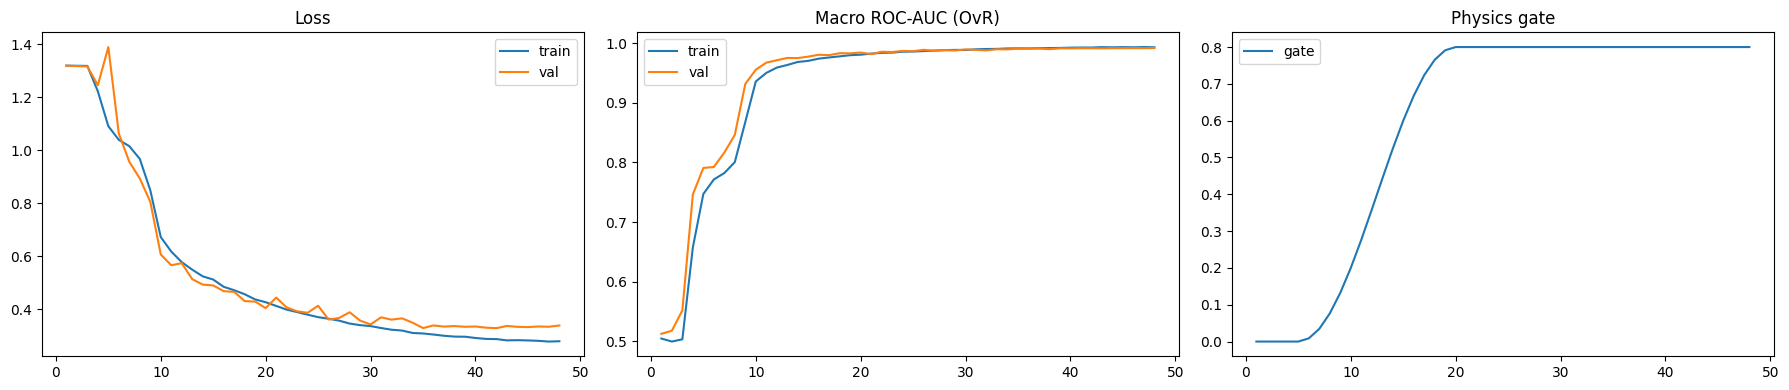

In [29]:

# =========================
# 13) Training curves
# =========================
hist_df = pd.read_csv(os.path.join(CFG.work_dir, "history.csv"))
display(hist_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["train_macro_auc_ovr"], label="train")
axes[1].plot(hist_df["epoch"], hist_df["val_macro_auc_ovr"], label="val")
axes[1].set_title("Macro ROC-AUC (OvR)")
axes[1].legend()

axes[2].plot(hist_df["epoch"], hist_df["train_physics_gate"], label="gate")
axes[2].set_title("Physics gate")
axes[2].legend()

plt.tight_layout()
plt.show()


In [30]:

# =========================
# 14) TTA inference (best checkpoint only)
# =========================
def d4_transforms(x: torch.Tensor):
    outs = []
    for k in range(4):
        xr = torch.rot90(x, k, dims=(-2, -1))
        outs.append(xr)
        outs.append(torch.flip(xr, dims=(-1,)))
    return outs


@torch.no_grad()
def predict_probs(model, loader, checkpoint_path=None, use_tta=True, gate=None):
    if checkpoint_path is None:
        checkpoint_path = os.path.join(CFG.work_dir, "best.pth")

    state_dict, state_obj = load_checkpoint_state(checkpoint_path, DEVICE)
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    this_gate = gate
    if this_gate is None:
        cfg_from_ckpt = state_obj.get("config", {}) if isinstance(state_obj, dict) else {}
        this_gate = float(cfg_from_ckpt.get("physics_gate_max", getattr(CFG, "physics_gate_max", 1.0)))
    model.set_physics_gate(this_gate)

    probs_list, targets_list, paths_list = [], [], []

    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["label"].cpu().numpy().astype(np.int64)

        if use_tta:
            logits_tta = []
            for xt in d4_transforms(x):
                logits, _ = model(xt)
                logits_tta.append(logits.float())
            logits = torch.stack(logits_tta, dim=0).mean(dim=0)
        else:
            logits, _ = model(x)
            logits = logits.float()

        probs = torch.softmax(logits, dim=1)
        probs = probs / probs.sum(dim=1, keepdim=True).clamp_min(1e-12)

        probs_list.append(probs.cpu().numpy().astype(np.float64))
        targets_list.append(y)
        paths_list.extend(batch["path"])

    probs_np = np.concatenate(probs_list, axis=0)
    targets_np = np.concatenate(targets_list, axis=0)

    pred_df = pd.DataFrame({
        "path": paths_list,
        "label": targets_np,
        "label_name": [IDX_TO_CLASS[i] for i in targets_np.tolist()],
        "pred": probs_np.argmax(axis=1),
        "pred_name": [IDX_TO_CLASS[i] for i in probs_np.argmax(axis=1).tolist()],
    })
    for i, c in enumerate(CFG.class_names):
        pred_df[f"p_{c}"] = probs_np[:, i]

    metrics = multiclass_metrics(targets_np, probs_np)
    return metrics, pred_df

best_metrics, best_pred_df = predict_probs(model, val_loader, checkpoint_path=os.path.join(CFG.work_dir, "best.pth"), use_tta=CFG.use_d4_tta)
best_pred_df.to_csv(os.path.join(CFG.work_dir, "val_predictions_best_tta.csv"), index=False)

print("BEST:", {k: v for k, v in best_metrics.items() if k not in ["y_pred", "per_class_auc"]})
print("BEST per-class auc:", best_metrics["per_class_auc"])


BEST: {'accuracy': 0.9557333333333333, 'macro_f1': 0.9555917153386454, 'weighted_f1': 0.9555917153386455, 'macro_auc_ovr': 0.9931187733333333, 'weighted_auc_ovr': 0.9931187733333334}
BEST per-class auc: {'no': 0.9939364, 'sphere': 0.9894832, 'vort': 0.9959367200000001}


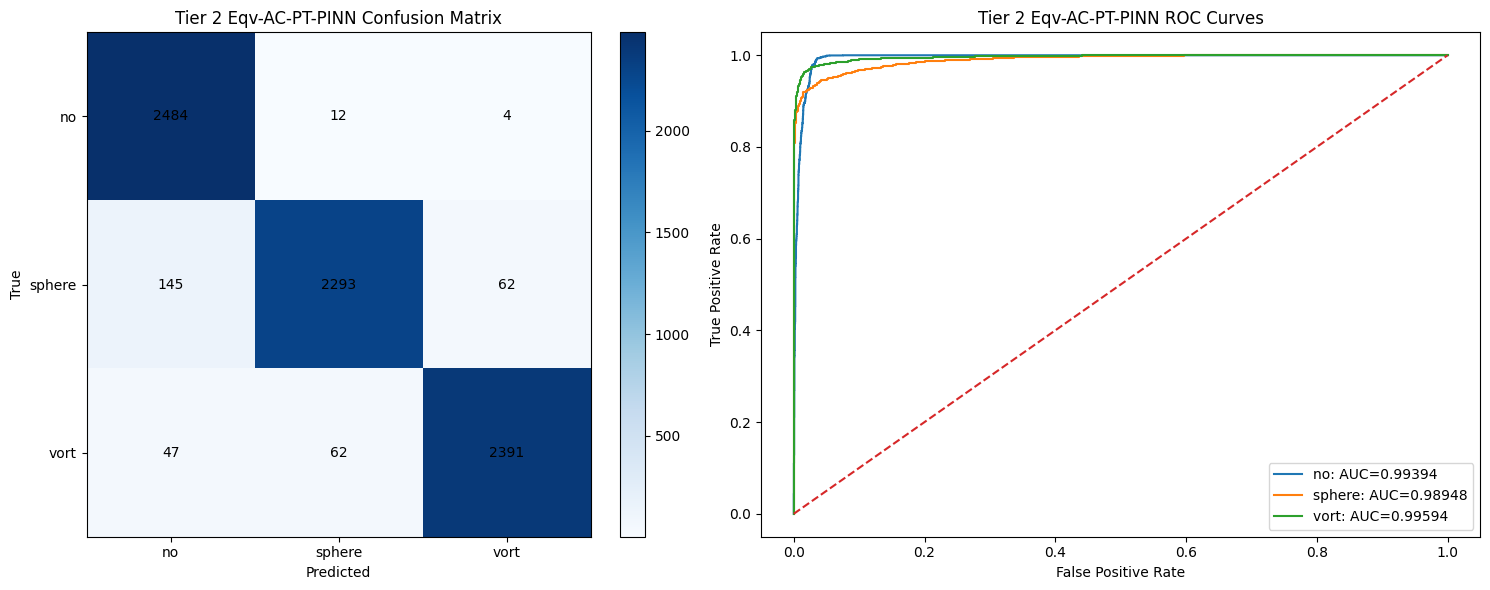

In [31]:

# =========================
# 15) Confusion matrix + ROC curves
# =========================
def plot_confusion_and_roc(pred_df: pd.DataFrame, title_prefix: str):
    y_true = pred_df["label"].values
    probs = pred_df[[f"p_{c}" for c in CFG.class_names]].values
    y_pred = probs.argmax(axis=1)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CFG.class_names))))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{title_prefix} Confusion Matrix")
    ax.set_xticks(range(len(CFG.class_names)))
    ax.set_yticks(range(len(CFG.class_names)))
    ax.set_xticklabels(CFG.class_names)
    ax.set_yticklabels(CFG.class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1]
    for i, c in enumerate(CFG.class_names):
        y_bin = (y_true == i).astype(np.int32)
        fpr, tpr, _ = roc_curve(y_bin, probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{c}: AUC={roc_auc:.5f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(f"{title_prefix} ROC Curves")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_confusion_and_roc(best_pred_df, "Tier 2 Eqv-AC-PT-PINN")


In [32]:

# =========================
# 16) Classification report
# =========================
print(classification_report(
    best_pred_df["label"].values,
    best_pred_df["pred"].values,
    target_names=list(CFG.class_names),
    digits=5,
))


              precision    recall  f1-score   support

          no    0.92825   0.99360   0.95981      2500
      sphere    0.96874   0.91720   0.94226      2500
        vort    0.97314   0.95640   0.96470      2500

    accuracy                        0.95573      7500
   macro avg    0.95671   0.95573   0.95559      7500
weighted avg    0.95671   0.95573   0.95559      7500

